In [5]:
from google.colab import files
import pandas as pd

# Upload files
uploaded = files.upload()

# Read CSVs
income = pd.read_csv("NFLX_income.csv", index_col=0)
balance = pd.read_csv("NFLX_balance.csv", index_col=0)
cashflow = pd.read_csv("NFLX_cashflow.csv", index_col=0)
stock = pd.read_csv("NFLX_stock_history.csv")


Saving NFLX_balance.csv to NFLX_balance (1).csv
Saving NFLX_cashflow.csv to NFLX_cashflow (1).csv
Saving NFLX_stock_history.csv to NFLX_stock_history (1).csv
Saving NFLX_income.csv to NFLX_income (1).csv
                                                      2025-12-31  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.370000e-01   
Normalized EBITDA                                   3.025462e+10   
Net Income From Continuing Operation Net Minori...  1.098120e+10   
Reconciled Depreciation                             1.675556e+10   

                                                      2024-12-31  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  1.300000e-01   
Normalized EBITDA                                   2.631482e+10   
Net Income From Continuing Operation Net Minori...  8.711631e+09   
Reconciled Depreciation                        

In [35]:
# Drop 2021 if it exists, since values are null
for df in [income, balance, cashflow]:
    if '2021-12-31' in df.columns:
        df.drop(columns='2021-12-31', inplace=True)

# transpose to have years as rows
income_t = income.T
balance_t = balance.T
cashflow_t = cashflow.T

# Check
print("Income (transposed):\n", income_t.head())

Income (transposed):
             Tax Effect Of Unusual Items  Tax Rate For Calcs  \
2025-12-31                          0.0               0.137   
2024-12-31                          0.0               0.130   
2023-12-31                          0.0               0.130   
2022-12-31                          0.0               0.150   

            Normalized EBITDA  \
2025-12-31       3.025462e+10   
2024-12-31       2.631482e+10   
2023-12-31       2.150839e+10   
2022-12-31       2.033296e+10   

            Net Income From Continuing Operation Net Minority Interest  \
2025-12-31                                       1.098120e+10            
2024-12-31                                       8.711631e+09            
2023-12-31                                       5.407990e+09            
2022-12-31                                       4.491924e+09            

            Reconciled Depreciation  Reconciled Cost Of Revenue        EBITDA  \
2025-12-31             1.675556e+10         

In [53]:
#Check if there are any problematic null values
print("Income nulls:\n", income_t.isnull().sum())
print("\nBalance nulls:\n", balance_t.isnull().sum())
print("\nCashflow nulls:\n", cashflow_t.isnull().sum())
print("\nStock nulls:\n", stock.isnull().sum())

#Make sure the data is formatted correctly
print(income_t.dtypes)
print(balance_t.dtypes)
print(cashflow_t.dtypes)
print(stock.dtypes)

Income nulls:
 Tax Effect Of Unusual Items                                   0
Tax Rate For Calcs                                            0
Normalized EBITDA                                             0
Net Income From Continuing Operation Net Minority Interest    0
Reconciled Depreciation                                       0
Reconciled Cost Of Revenue                                    0
EBITDA                                                        0
EBIT                                                          0
Net Interest Income                                           0
Interest Expense                                              0
Interest Income                                               1
Normalized Income                                             0
Net Income From Continuing And Discontinued Operation         0
Total Expenses                                                0
Total Operating Income As Reported                            0
Diluted Average Shares   

In [54]:
# Convert index to datetime first (so sorting works correctly)
for df in [income_t, balance_t, cashflow_t]:
    df.index = pd.to_datetime(df.index)

# Sort index ascending (oldest to newest)
for df in [income_t, balance_t, cashflow_t]:
    df.sort_index(inplace=True)

# Optional: convert index back to just year string for readability
for df in [income_t, balance_t, cashflow_t]:
    df.index = df.index.year.astype(str)


In [55]:
income_t['Net Profit Margin'] = income_t['Net Income From Continuing Operation Net Minority Interest'] / income_t['Total Revenue']
income_t['EBITDA Margin'] = income_t['Normalized EBITDA'] / income_t['Total Revenue']

In [56]:
 balance_t['Current Ratio'] = balance_t['Current Assets'] / balance_t['Current Liabilities']

In [57]:
income_t['ROA'] = income_t['Net Income From Continuing Operation Net Minority Interest'] / balance_t['Total Assets']
income_t['ROE'] = income_t['Net Income From Continuing Operation Net Minority Interest'] / balance_t['Stockholders Equity']

In [58]:
balance_t['Debt-to-Equity'] = balance_t['Total Liabilities Net Minority Interest'] / balance_t['Stockholders Equity']
balance_t['Debt Ratio'] = balance_t['Total Liabilities Net Minority Interest'] / balance_t['Total Assets']

In [66]:
cashflow_t['Free Cash Flow'] = cashflow_t['Operating Cash Flow'] - cashflow_t['Capital Expenditure']

In [60]:
stock['Daily Return'] = stock['Close'].pct_change()

In [70]:
summary = pd.DataFrame({
    'Net Profit Margin': income_t['Net Profit Margin'],
    'EBITDA Margin': income_t['EBITDA Margin'],
    'ROA': income_t['ROA'],
    'ROE': income_t['ROE'],
    'Current Ratio': balance_t['Current Ratio'],
    'Debt-to-Equity': balance_t['Debt-to-Equity'],
    'Debt Ratio': balance_t['Debt Ratio'],
    'Free Cash Flow': cashflow_t['Free Cash Flow'],
})
print(summary)

      Net Profit Margin  EBITDA Margin       ROA       ROE  Current Ratio  \
2022           0.142080       0.643131  0.092436  0.216193       1.168390   
2023           0.160364       0.637790  0.110974  0.262673       1.119345   
2024           0.223370       0.674722  0.162438  0.352077       1.218028   
2025           0.243038       0.669601  0.197514  0.412587       1.185709   

      Debt-to-Equity  Debt Ratio  Free Cash Flow  
2022        1.338828    0.572435    2.433986e+09  
2023        1.366974    0.577520    7.622853e+09  
2024        1.167447    0.538628    7.800902e+09  
2025        1.088896    0.521278    1.083749e+10  


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1200x600 with 0 Axes>

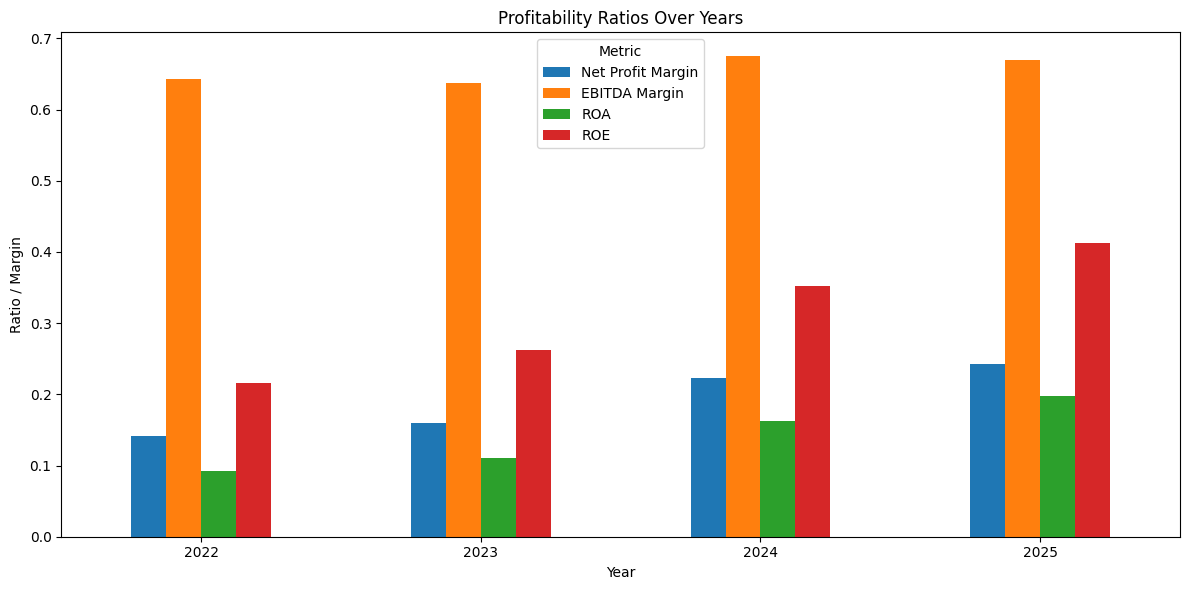

<Figure size 1200x600 with 0 Axes>

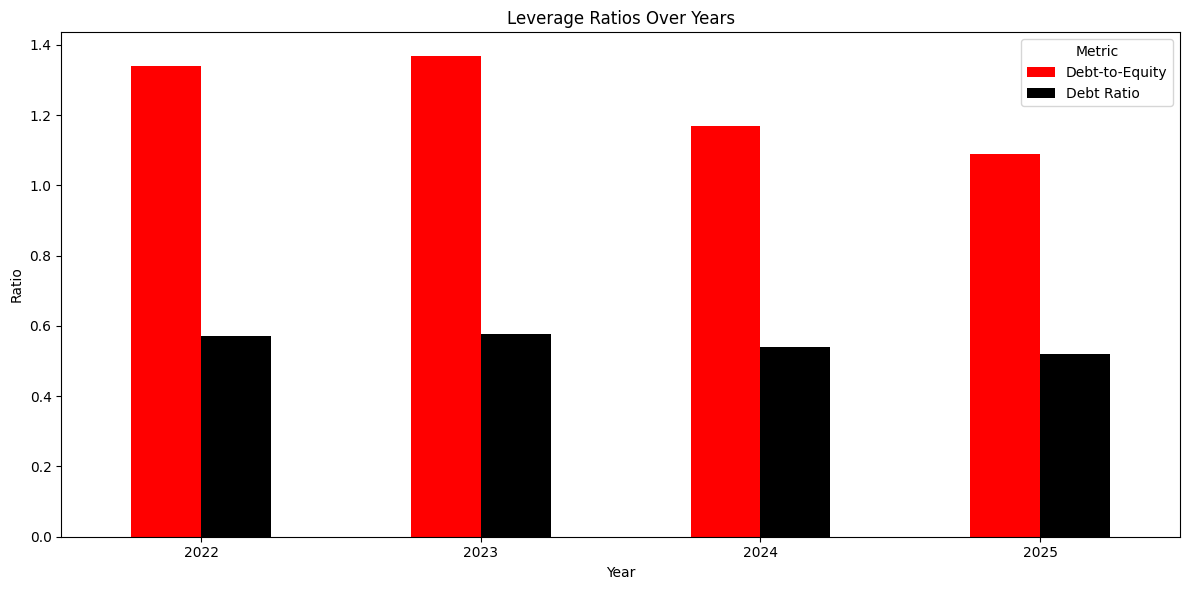

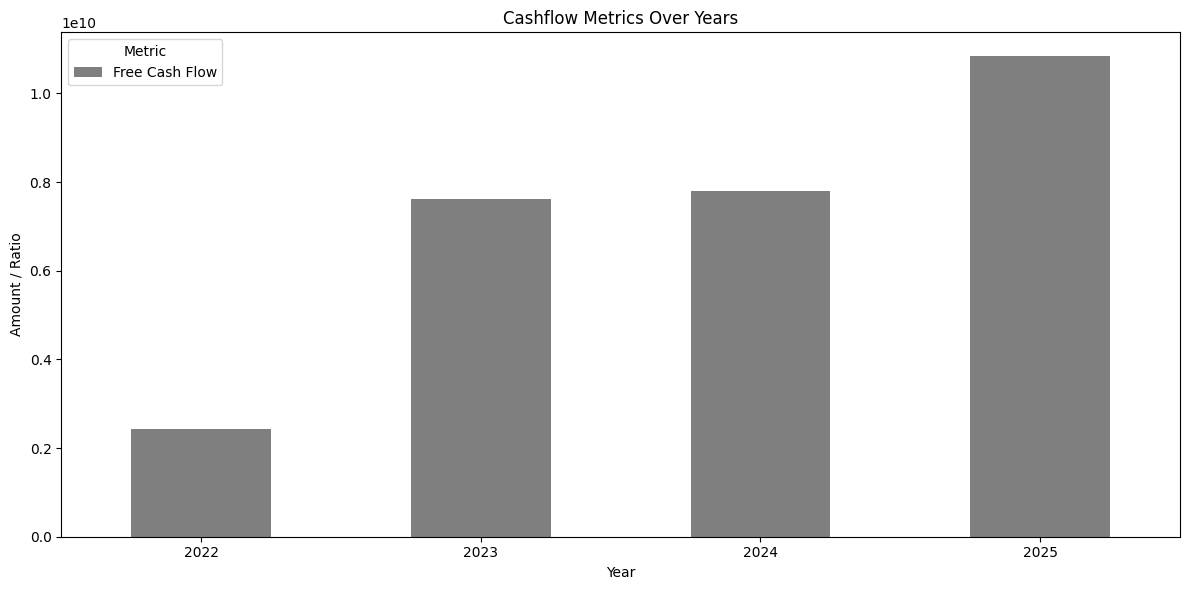

In [69]:
plt.figure(figsize=(12,6))
summary[['Net Profit Margin','EBITDA Margin','ROA','ROE']].plot(
    kind='bar',
    figsize=(12,6),
    color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    title='Profitability Ratios Over Years'
)
plt.ylabel('Ratio / Margin')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# --- Leverage Ratios ---
plt.figure(figsize=(12,6))
summary[['Debt-to-Equity','Debt Ratio']].plot(
    kind='bar',
    figsize=(12,6),
    color=['Red', 'Black'],
    title='Leverage Ratios Over Years'
)
plt.ylabel('Ratio')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

# --- Cashflow Metrics ---
plt.figure(figsize=(12,6))
summary['Free Cash Flow'].plot(
    kind='bar',
    figsize=(12,6),
    color=['#7f7f7f'],
    title='Cashflow Metrics Over Years'
)
plt.ylabel('Amount / Ratio')
plt.xlabel('Year')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()
